In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [20]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import json

In [7]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
 "latitude": -33.45,
 "longitude": -70.65,
 "current_weather": True
}
response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()
print(f"Codigo de estado : {response.status_code}")
print(f"URL final : {response.url}")
print(f"Clima actual : {data['current_weather']}")

Codigo de estado : 200
URL final : https://api.open-meteo.com/v1/forecast?latitude=-33.45&longitude=-70.65&current_weather=True
Clima actual : {'time': '2026-06-10T15:00', 'interval': 900, 'temperature': 8.7, 'windspeed': 5.3, 'winddirection': 55, 'is_day': 1, 'weathercode': 61}


In [8]:
# Explorar el JSON antes de procesarlo
print("Claves principales:", list(data.keys()))
# Ver el JSON formateado
print(json.dumps(data, indent=4))

Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_weather_units', 'current_weather']
{
    "latitude": -33.427067,
    "longitude": -70.64276,
    "generationtime_ms": 0.12695789337158203,
    "utc_offset_seconds": 0,
    "timezone": "GMT",
    "timezone_abbreviation": "GMT",
    "elevation": 554.0,
    "current_weather_units": {
        "time": "iso8601",
        "interval": "seconds",
        "temperature": "\u00b0C",
        "windspeed": "km/h",
        "winddirection": "\u00b0",
        "is_day": "",
        "weathercode": "wmo code"
    },
    "current_weather": {
        "time": "2026-06-10T15:00",
        "interval": 900,
        "temperature": 8.7,
        "windspeed": 5.3,
        "winddirection": 55,
        "is_day": 1,
        "weathercode": 61
    }
}


In [ ]:
#Ejercicio 2

Preguntas de reflexion
• ¿Qué ocurre si cambias timeout=10 por timeout=0?00001? ¿Qué excepción se lanza?
• ¿Qué diferencia hay entre response?text y response.json()?
• Identifica en response.url como fueron codificados los parámetros que pasaste en params.

1) El tiempo de espera se reduce drasticamente, tirando el error de timeout
2) Lanza un error de http de excepcion
3) Puede ser util es response porque alerta con el debido parametro programable en caso de timeout o desconexión del mismo.

In [16]:
def get_seguro(url, params=None, timeout=10):
    """GET robusto con manejo de errores. Retorna el dict JSON o None si ocurre error."""
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r.json()
    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondio en {timeout}s")
    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")
        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Limite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print("No autorizado. Verificar API key.")
    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexion o host invalido")
    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")
    return None
    # Pruebass
r1 = get_seguro(
    "https://api.open-meteo.com/v1/forecast", 
    params={"latitude": -33.45, "longitude": -70.65, "current_weather": True}
)
print("Caso 1 (valido):", r1["current_weather"] if r1 else "None")

r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2 (404):", r2)

r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3 (timeout):", r3)

[ERROR] Timeout: la API no respondio en 10s
Caso 1 (valido): None
[ERROR] HTTP 404: Not Found
Endpoint no encontrado. Revisa la URL.
Caso 2 (404): None
[ERROR] Timeout: la API no respondio en 1e-05s
Caso 3 (timeout): None


Preguntas de reflexión
• ¿Por qué es peligroso un script sin timeout= que consume APIs externas?
• ¿Qué estrategia usarías si la API retorna 429 de forma intermitente?
• ¿Qué diferencia hay entre ConnectionError y Timeout en términos de caua?


1) Si, porque los request no tienen tiempo de espera límite como tal
2) Significa "Too many request" que es la forma en la que retorna demasiadas consultas.
3) Uno se debe a la desconexión (sin internet) y otro se debe a que el tiempo de espera de respuesta se agotó.

In [ ]:
#Ejercicio 3

In [17]:
def consumir_paginado(url, limite=20, max_paginas=20):
    """Consume API con paginacion tipo page+limit. Retorna lista con todos los registros."""
    todos = []
    pagina = 1
    
    while pagina <= max_paginas:
        resultado = get_seguro(url, params={"_page": pagina, "_limit": limite})
        
        if resultado is None:
            break
            
        if not resultado:
            print(f"Fin de datos en pagina {pagina}")
            break
            
        todos.extend(resultado)
        print(f"Pagina {pagina:2d}: [{len(resultado):3d}] registros | Total: {len(todos)}")
        
        pagina += 1
        time.sleep(0.1)
        
    return todos

print("Descargando posts...")
posts = consumir_paginado("https://jsonplaceholder.typicode.com/posts", limite=20)
df_posts = pd.DataFrame(posts)

print(f"\nForma del DataFrame: {df_posts.shape}")
print("\nPrimeras filas:")
print(df_posts.head())
print("\nTipos de datos:")
print(df_posts.dtypes)

resumen = df_posts.groupby("userId").agg(
    total_posts=("id", "count"),
    largo_promedio=("body", lambda x: x.str.len().mean().round(1))
).reset_index()

print("\n", resumen)

df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)
print("\nArchivos CSV exportados correctamente.")

Descargando posts...
Pagina  1: [ 20] registros | Total: 20
Pagina  2: [ 20] registros | Total: 40
Pagina  3: [ 20] registros | Total: 60
Pagina  4: [ 20] registros | Total: 80
Pagina  5: [ 20] registros | Total: 100
Fin de datos en pagina 6

Forma del DataFrame: (100, 4)

Primeras filas:
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quae

Preguntas de reflexión
• ¿Que ocurre si la API devuelve una lista vacía en la primera página?
• ¿Para qué sirve el parámetro max_paginas en la función?
• ¿Qué ventaja ofrece pd.DataFrame(lista_de_dicts) frente a construir el DataFrame
manualmente?

1) Se debe a que principalmente el if not resultado que trabaja, se activa de inmediato al evaluar la lista falsa
2) Funciona por asi decirlo como un mecanismo de seguridad, ante el control de flujo.
3) Ofrece eficiencia y simplicidad, gracias a la optimización de pandas frente a cada diccionario de la lista.

In [ ]:
#Ejercicio 4

Extrayendo Santiago...
Extrayendo Concepcion...
Extrayendo Antofagasta...
Extraccion completa.

        ciudad       fecha  temp_max  temp_min  temp_prom
0  Antofagasta  2026-06-10      17.8      13.8       15.6
1  Antofagasta  2026-06-11      18.6      14.6       16.1
2  Antofagasta  2026-06-12      18.7      14.1       16.3
3   Concepcion  2026-06-10      13.4       7.4       10.8
4   Concepcion  2026-06-11      11.8       4.7        8.4
5   Concepcion  2026-06-12      11.6       8.5       10.4
6     Santiago  2026-06-10      11.5       7.1        8.9
7     Santiago  2026-06-11      16.0       3.4        9.6
8     Santiago  2026-06-12      19.1      10.6       13.9

CSV exportado: resumen_clima.csv


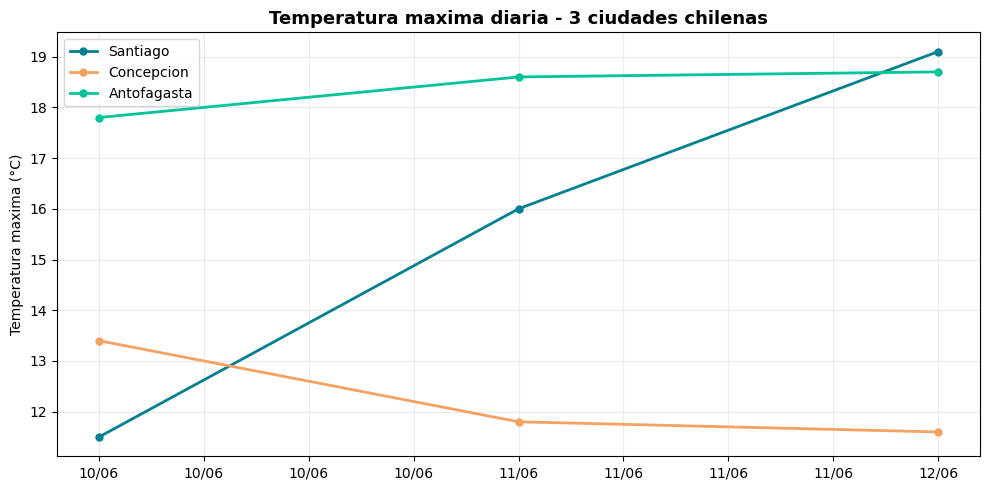

Grafico guardado: comparacion_temp.png


In [23]:
# 1. Paso 1 (Extract)
def obtener_clima(lat, lon, dias=3):
    """Retorna DataFrame con temperatura horaria para una ubicacion."""
    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "hourly": "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone": "America/Santiago"
        }
    )
    if data is None:
        return None
        
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df

CIUDADES = {
    "Santiago": (-33.45, -70.65),
    "Concepcion": (-36.82, -73.04),
    "Antofagasta": (-23.65, -70.40),
}

datos = {}
for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3)
print("Extraccion completa.\n")

# 2. Paso 2 (Transform)
frames = []
for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"] = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

resumen_diario = df_all.groupby(["ciudad", "fecha"]).agg(
    temp_max=("temperature_2m", "max"),
    temp_min=("temperature_2m", "min"),
    temp_prom=("temperature_2m", "mean")
).round(1).reset_index()

print(resumen_diario)

# 3. Paso 3 (Load + Visualizar)
resumen_diario.to_csv("resumen_clima.csv", index=False)
print("\nCSV exportado: resumen_clima.csv")

fig, ax = plt.subplots(figsize=(10,5))
colores = ["#028090", "#F4A261", "#02C39A"]

for (ciudad, color) in zip(CIUDADES.keys(), colores):
    df_c = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])
    ax.plot(fechas, df_c["temp_max"], marker="o", label=ciudad, color=color, linewidth=2, markersize=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_title("Temperatura maxima diaria - 3 ciudades chilenas", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatura maxima (°C)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grafico guardado: comparacion_temp.png")

Preguntas de reflexion
• ¿Por que es importante llamar plt.tight_layout() antes de savefig()?
• ¿Como modificarías el código para agregar una cuarta ciudad sin cambiar la estructura
principal?
• Describe el pipeline ETL que implementaste en esta actividad con tus propias palabras

1) Porque distribuye de mejor manera los elementos del gráfico.
2) Se podrían cambiar las variables por así decirlo del código, añadiendo al diccionario del código el nombre de la ciudad
con su longitud y latitud correspondiente, además de añadirle un color caracteristico y los protocolos definidos anteriormente, haran que
la ciudad por defecto aparezca en el gráfico.
3) Se extrae la información previa para así transformarla puramente en información que nos sirve para datos de indetificacion por ciudad, principalmente lo esencial, luego se almacenan los resultados en un archivo csv.